In [1]:
import sys

print("Python Version:", sys.version)
print("NLP InsightHub Setup Started!")

Python Version: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
NLP InsightHub Setup Started!


In [5]:
%pip install pandas numpy nltk spacy scikit-learn matplotlib seaborn wordcloud transformers torch streamlit

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import nltk
import spacy
import sklearn
import transformers
import torch

print("✅ Pandas:", pd.__version__)
print("✅ NumPy:", np.__version__)
print("✅ NLTK:", nltk.__version__)
print("✅ spaCy:", spacy.__version__)
print("✅ Scikit-learn:", sklearn.__version__)
print("✅ Transformers:", transformers.__version__)
print("✅ PyTorch:", torch.__version__)

print("\n🎉 NLP InsightHub Environment Ready!")

C:\Users\think paid\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Pandas: 3.0.5
✅ NumPy: 2.5.2
✅ NLTK: 3.10.3
✅ spaCy: 3.8.16
✅ Scikit-learn: 1.9.0
✅ Transformers: 5.16.0
✅ PyTorch: 2.13.0+cpu

🎉 NLP InsightHub Environment Ready!


In [7]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

print("✅ NLTK resources downloaded!")

[nltk_data] Downloading package punkt to C:\Users\think
[nltk_data]     paid\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\think
[nltk_data]     paid\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\think
[nltk_data]     paid\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


✅ NLTK resources downloaded!


[nltk_data] Downloading package wordnet to C:\Users\think
[nltk_data]     paid\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [8]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenization
    tokens = nltk.word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

print("✅ Preprocessing function created!")

✅ Preprocessing function created!


In [9]:
sample_text = """
I am learning Natural Language Processing.
NLP is amazing and I really enjoy working with text data!
"""

processed = preprocess_text(sample_text)

print("Original Text:")
print(sample_text)

print("\nProcessed Tokens:")
print(processed)

Original Text:

I am learning Natural Language Processing.
NLP is amazing and I really enjoy working with text data!


Processed Tokens:
['learning', 'natural', 'language', 'processing', 'nlp', 'amazing', 'really', 'enjoy', 'working', 'text', 'data']


In [10]:
def text_statistics(text, processed_tokens):
    words = text.split()
    
    stats = {
        "Characters": len(text),
        "Words": len(words),
        "Processed Words": len(processed_tokens),
        "Unique Words": len(set(processed_tokens)),
        "Average Word Length": round(
            sum(len(word) for word in processed_tokens) / len(processed_tokens), 2
        ) if processed_tokens else 0
    }
    
    return stats


stats = text_statistics(sample_text, processed)

for key, value in stats.items():
    print(f"{key}: {value}")

Characters: 102
Words: 17
Processed Words: 11
Unique Words: 11
Average Word Length: 6.27


In [11]:
from collections import Counter

word_frequency = Counter(processed)

print("Top 10 Most Frequent Words:\n")

for word, count in word_frequency.most_common(10):
    print(f"{word}: {count}")

Top 10 Most Frequent Words:

learning: 1
natural: 1
language: 1
processing: 1
nlp: 1
amazing: 1
really: 1
enjoy: 1
working: 1
text: 1


Matplotlib is building the font cache; this may take a moment.


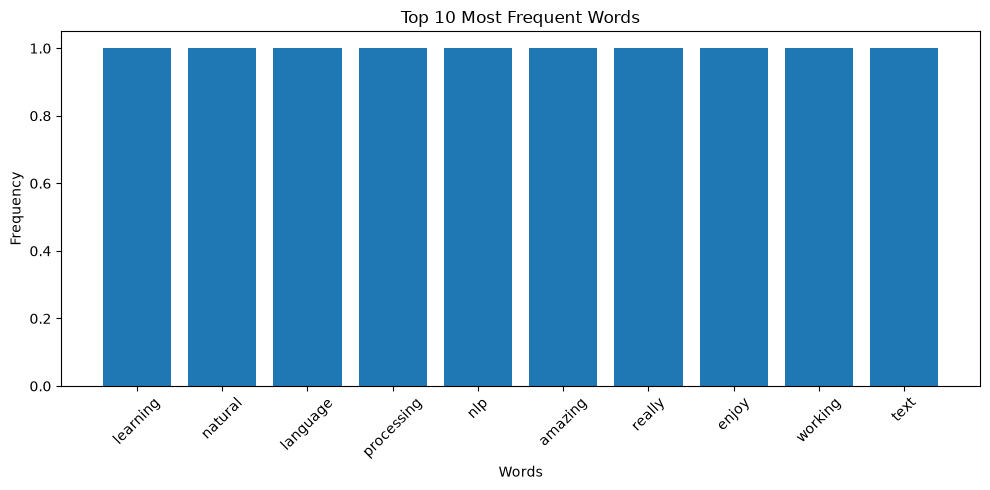

In [12]:
import matplotlib.pyplot as plt

words = [word for word, count in word_frequency.most_common(10)]
counts = [count for word, count in word_frequency.most_common(10)]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

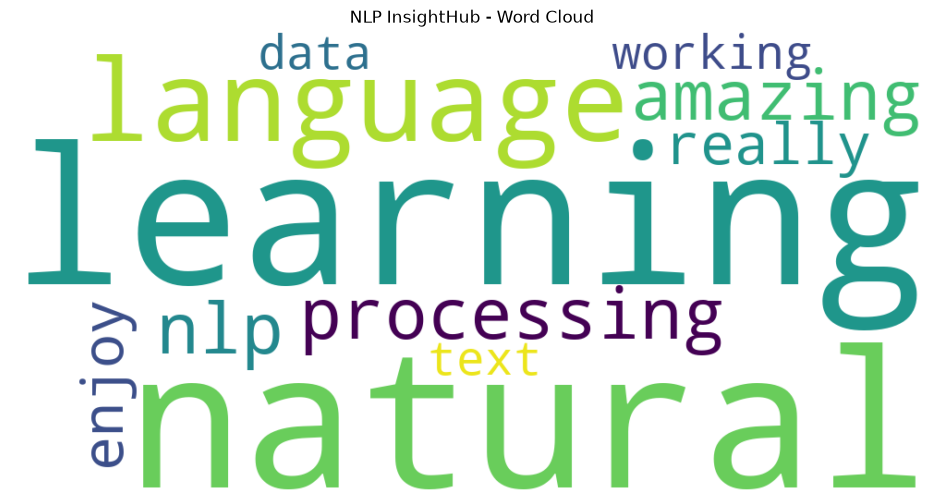

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_for_cloud = " ".join(processed)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text_for_cloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("NLP InsightHub - Word Cloud")
plt.show()

In [14]:
from transformers import pipeline

sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

print("✅ Sentiment Analysis Model Loaded!")

C:\Users\think paid\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\think paid\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1

✅ Sentiment Analysis Model Loaded!


In [15]:
text = "I really enjoyed this project. The NLP results are amazing!"

result = sentiment_analyzer(text)

print("Text:", text)
print("Sentiment:", result[0]["label"])
print("Confidence:", round(result[0]["score"] * 100, 2), "%")

Text: I really enjoyed this project. The NLP results are amazing!
Sentiment: POSITIVE
Confidence: 99.99 %


In [16]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.6/12.8 MB 8.7 MB/s eta 0:00:02
     --------- ------------------------------ 2.9/12.8 MB 7.5 MB/s eta 0:00:02
     ------------- -------------------------- 4.5/12.8 MB 7.1 MB/s eta 0:00:02
     ---------------- ----------------------- 5.2/12.8 MB 7.4 MB/s eta 0:00:02
     ------------------- -------------------- 6.3/12.8 MB 6.0 MB/s eta 0:00:02
     ------------------------- -------------- 8.1/12.8 MB 6.6 MB/s eta 0:00:01
     ----------------------------- ---------- 9.4/12.8 MB 6.6 MB/s eta 0:00:01
     --------------------------------- ------ 10.7/12.8 MB 6.5 MB/s eta 0:00:01
     ------------------------------------- -- 12.1/12.8 MB 6.5 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 6.3 MB/s  0:00:02
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [17]:
import spacy

nlp = spacy.load("en_core_web_sm")

print("✅ NER Model Loaded!")

✅ NER Model Loaded!


In [18]:
text = """
Reva is studying at Pune University.
She wants to work at Microsoft in Bangalore.
The company was founded in 1975.
"""

doc = nlp(text)

print("Named Entities:\n")

for entity in doc.ents:
    print(f"{entity.text:20} → {entity.label_}")

Named Entities:

Pune University      → ORG
Microsoft            → ORG
Bangalore            → GPE
1975                 → DATE


In [19]:
import pandas as pd

def extract_entities(text):
    doc = nlp(text)

    entities = []

    for entity in doc.ents:
        entities.append({
            "Entity": entity.text,
            "Type": entity.label_,
            "Description": spacy.explain(entity.label_)
        })

    return pd.DataFrame(entities)


entity_df = extract_entities(text)

entity_df

,Entity,Type,Description
0,Pune University,ORG,"Companies, agencies, institutions, etc."
1,Microsoft,ORG,"Companies, agencies, institutions, etc."
2,Bangalore,GPE,"Countries, cities, states"
3,1975,DATE,Absolute or relative dates or periods


In [20]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

print("✅ Text Classification Model Loaded!")

C:\Users\think paid\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\think paid\.cache\huggingface\hub\models--facebook--bart-large-mnli. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 515/515 [00:00<00:00, 1880.41it/s]


✅ Text Classification Model Loaded!


In [21]:
text = """
Microsoft announced a new artificial intelligence product
that will help businesses automate their customer service.
"""

categories = [
    "Technology",
    "Business",
    "Sports",
    "Politics",
    "Entertainment",
    "Education"
]

result = classifier(
    text,
    candidate_labels=categories
)

print("Text:")
print(text)

print("\nClassification Results:")
for label, score in zip(result["labels"], result["scores"]):
    print(f"{label:15} → {score * 100:.2f}%")

Text:

Microsoft announced a new artificial intelligence product
that will help businesses automate their customer service.


Classification Results:
Technology      → 58.80%
Business        → 22.06%
Entertainment   → 9.21%
Sports          → 4.30%
Politics        → 3.57%
Education       → 2.07%


In [22]:
def analyze_text(text):
    # 1. Preprocessing
    processed_tokens = preprocess_text(text)

    # 2. Statistics
    stats = text_statistics(text, processed_tokens)

    # 3. Word frequency
    frequency = Counter(processed_tokens)

    # 4. Sentiment
    sentiment_result = sentiment_analyzer(text)[0]

    # 5. Named Entity Recognition
    entity_df = extract_entities(text)

    # 6. Text classification
    categories = [
        "Technology",
        "Business",
        "Sports",
        "Politics",
        "Entertainment",
        "Education"
    ]

    classification_result = classifier(
        text,
        candidate_labels=categories
    )

    return {
        "processed_tokens": processed_tokens,
        "statistics": stats,
        "word_frequency": frequency,
        "sentiment": sentiment_result,
        "entities": entity_df,
        "classification": classification_result
    }


print("✅ Complete NLP Analyzer Created!")

✅ Complete NLP Analyzer Created!


In [23]:
user_text = """
Microsoft is developing new artificial intelligence tools in
Bangalore. The technology is helping businesses improve their
customer service and productivity.
"""

analysis = analyze_text(user_text)

print("========== NLP INSIGHTHUB ==========\n")

print("📊 TEXT STATISTICS")
for key, value in analysis["statistics"].items():
    print(f"{key}: {value}")

print("\n😊 SENTIMENT")
print("Label:", analysis["sentiment"]["label"])
print("Confidence:",
      round(analysis["sentiment"]["score"] * 100, 2), "%")

print("\n🏷️ CLASSIFICATION")
print("Category:", analysis["classification"]["labels"][0])
print("Confidence:",
      round(analysis["classification"]["scores"][0] * 100, 2), "%")

print("\n🔍 NAMED ENTITIES")
print(analysis["entities"])

print("\n🔑 TOP KEYWORDS")
for word, count in analysis["word_frequency"].most_common(10):
    print(f"{word}: {count}")

========== NLP INSIGHTHUB ==========

📊 TEXT STATISTICS
Characters: 159
Words: 20
Processed Words: 14
Unique Words: 14
Average Word Length: 8.29

😊 SENTIMENT
Label: POSITIVE
Confidence: 99.66 %

🏷️ CLASSIFICATION
Category: Technology
Confidence: 54.36 %

🔍 NAMED ENTITIES
      Entity    Type                              Description
0  Microsoft     ORG  Companies, agencies, institutions, etc.
1  Bangalore  PERSON              People, including fictional

🔑 TOP KEYWORDS
microsoft: 1
developing: 1
new: 1
artificial: 1
intelligence: 1
tool: 1
bangalore: 1
technology: 1
helping: 1
business: 1
